# Stock Universe, EDA & Preprocessing

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import MinMaxScaler

import os
import pickle

np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All imports successful.')

All imports successful.


In [ ]:
TICKERS = {
    'Banking' : 'HDFCBANK.NS',
    'IT'      : 'INFY.NS',
    'Pharma'  : 'SUNPHARMA.NS',
    'FMCG'    : 'HINDUNILVR.NS'
}

START_DATE     = '2021-01-01'
END_DATE       = '2025-12-31'
TRAIN_END      = '2025-06-30'
TEST_START     = '2025-07-01'
ROLLING_WINDOW = 30

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../outputs/plots',  exist_ok=True)

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP  = {v: k for k, v in TICKERS.items()}

print('Config ready. Stocks:', TICKER_LIST)

Config ready. Stocks: ['HDFCBANK.NS', 'INFY.NS', 'SUNPHARMA.NS', 'HINDUNILVR.NS']


---
## 1. Data Fetching

In [4]:
raw = yf.download(
    TICKER_LIST,
    start=START_DATE,
    end=END_DATE,
    interval='1d',
    auto_adjust=True,
    progress=True
)

close  = raw['Close'].copy()
volume = raw['Volume'].copy()

print('Shape:', close.shape)
print('Date range:', close.index[0].date(), 'to', close.index[-1].date())
close.head(3)

[*********************100%***********************]  4 of 4 completed


Shape: (1235, 4)
Date range: 2021-01-01 to 2025-12-30


Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,SUNPHARMA.NS
Date,,,,
2021-01-01,674.886414,2195.603760,1109.599609,562.592773
2021-01-04,670.600342,2231.422363,1134.072632,570.282898
2021-01-05,675.667664,2253.539062,1138.958496,569.386414


In [5]:
close.to_csv('../data/raw/close_prices.csv')
volume.to_csv('../data/raw/volume.csv')
print('Raw data saved.')

Raw data saved.


---
## 2. Preprocessing
### 2a. Handle Missing Values

In [6]:
print('Missing values BEFORE:')
print(close.isnull().sum())

close  = close.ffill().bfill()
volume = volume.ffill().bfill()

print('\nMissing values AFTER:')
print(close.isnull().sum())

Missing values BEFORE:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
SUNPHARMA.NS     0
dtype: int64

Missing values AFTER:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
INFY.NS          0
SUNPHARMA.NS     0
dtype: int64


### 2b. Train / Test Split
PS requirement: train = Jan 2021 – Jun 2025, test = Jul 2025 – Dec 2025

In [8]:
train_close = close[close.index <= TRAIN_END]
test_close  = close[close.index >= TEST_START]

print(f'Train: {train_close.index[0].date()} → {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()}  → {test_close.index[-1].date()}  ({len(test_close)} rows)')

Train: 2021-01-01 → 2025-06-30  (1110 rows)
Test : 2025-07-01  → 2025-12-30  (125 rows)


---
## 3. Price Plots

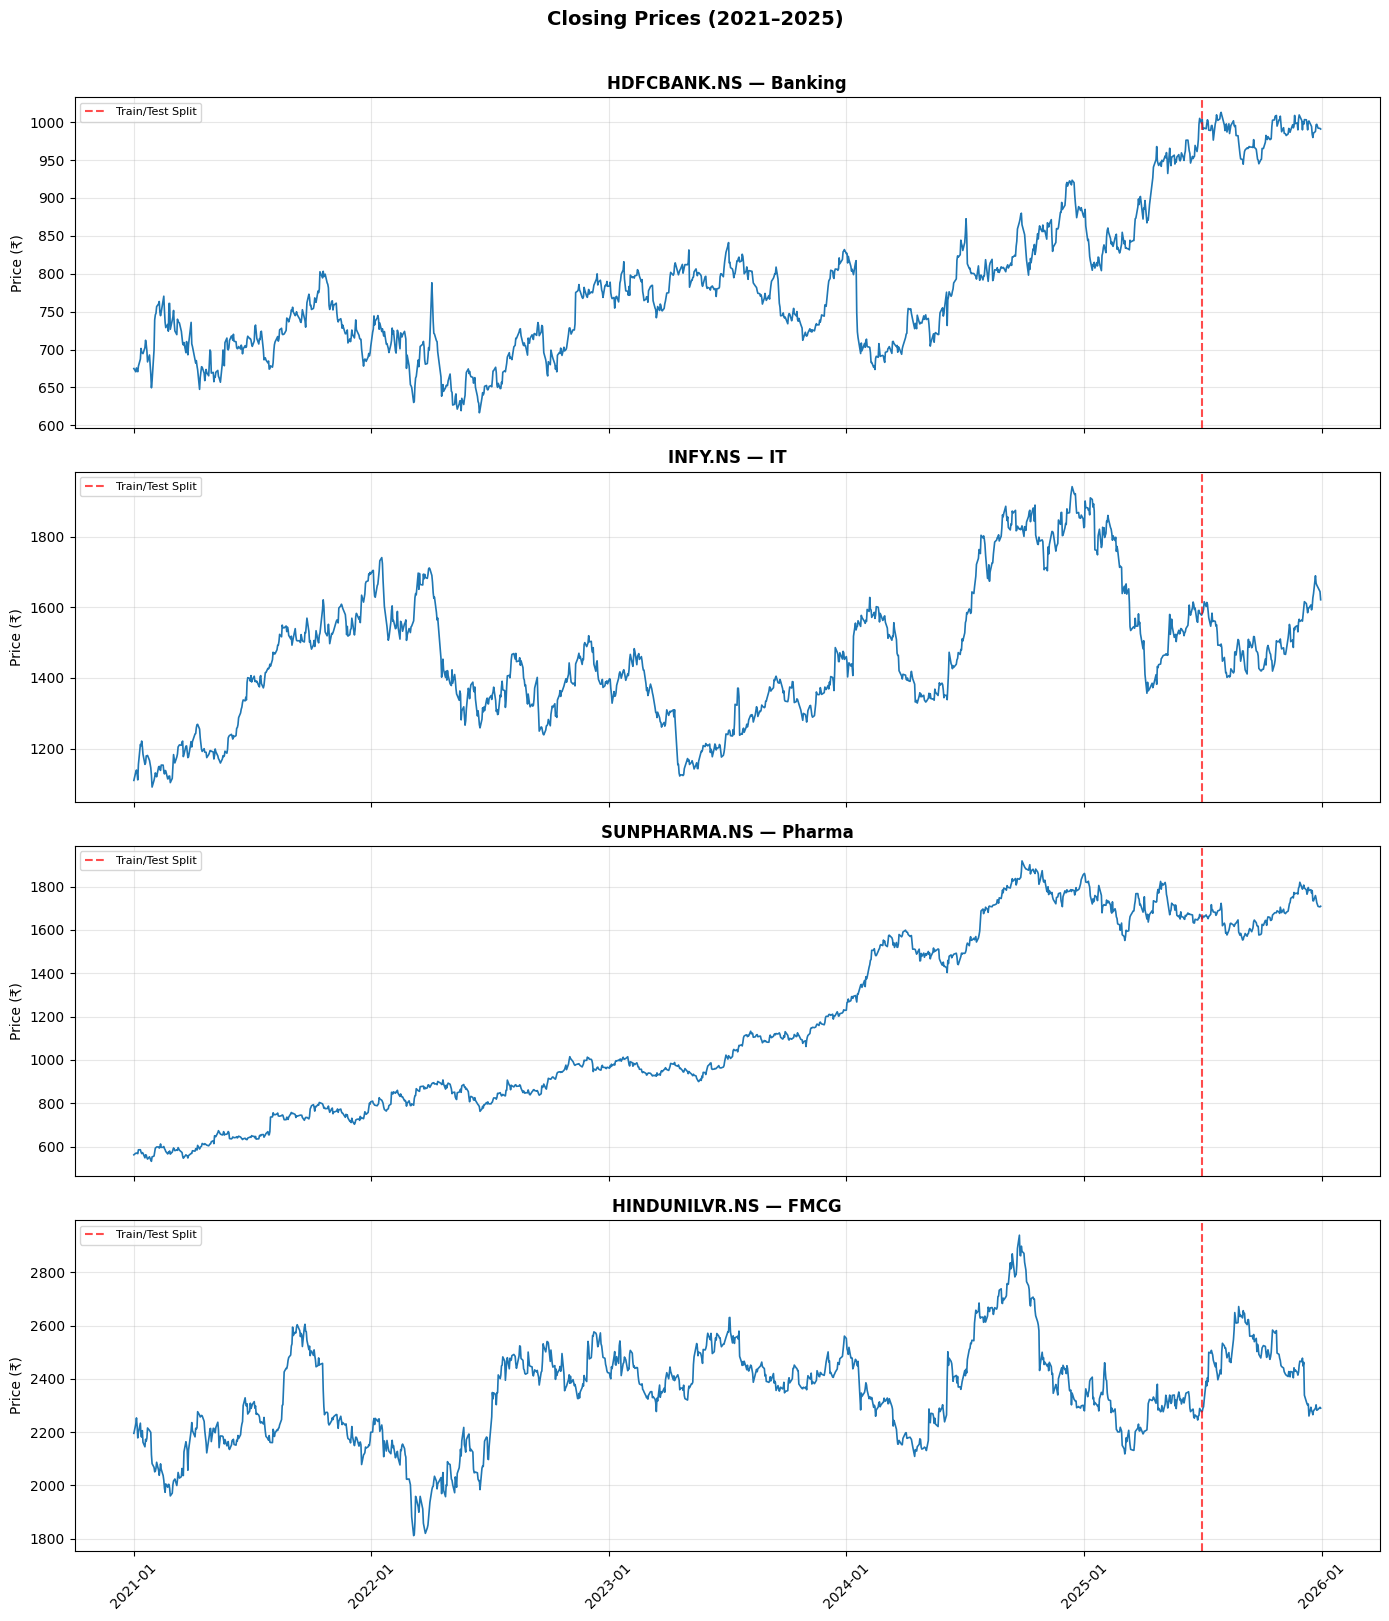

In [10]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4 * len(TICKER_LIST)), sharex=True)

for ax, ticker in zip(axes, TICKER_LIST):
    ax.plot(close.index, close[ticker], linewidth=1.2)
    ax.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', alpha=0.7, label='Train/Test Split')
    ax.set_title(f'{ticker} — {SECTOR_MAP[ticker]}', fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend(loc='upper left', fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.suptitle('Closing Prices (2021–2025)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/plots/01_closing_prices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Log Returns

In [11]:
log_returns = np.log(close / close.shift(1)).dropna()

print('Log returns shape:', log_returns.shape)
log_returns.describe().round(4)

Log returns shape: (1234, 4)


Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,SUNPHARMA.NS
count,1234.0000,1234.0000,1234.0000,1234.0000
mean,0.0003,0.0000,0.0003,0.0009
std,0.0134,0.0127,0.0152,0.0131
min,-0.0881,-0.0769,-0.0990,-0.0466
25%,-0.0065,-0.0068,-0.0083,-0.0066
50%,0.0005,-0.0003,0.0004,0.0006
75%,0.0070,0.0066,0.0091,0.0079
max,0.0954,0.0579,0.0763,0.0962


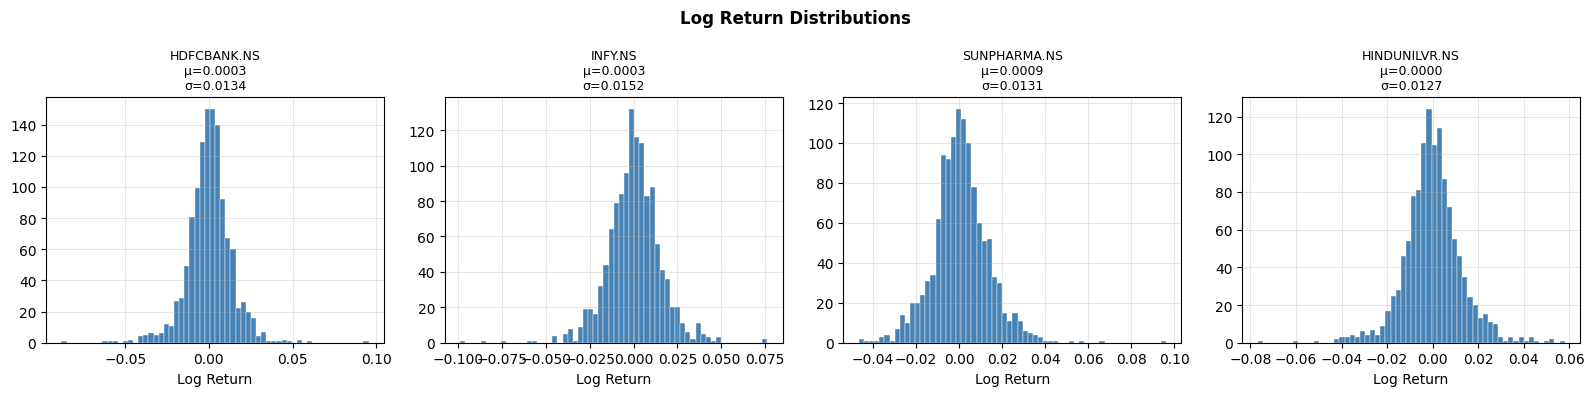

In [12]:
fig, axes = plt.subplots(1, len(TICKER_LIST), figsize=(16, 4))

for ax, ticker in zip(axes, TICKER_LIST):
    ax.hist(log_returns[ticker].dropna(), bins=60, edgecolor='white', linewidth=0.3, color='steelblue')
    ax.set_title(f'{ticker}\nμ={log_returns[ticker].mean():.4f}\nσ={log_returns[ticker].std():.4f}', fontsize=9)
    ax.set_xlabel('Log Return')

plt.suptitle('Log Return Distributions', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/02_log_return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Rolling Volatility (Task 1 — Stock Selection Justification)

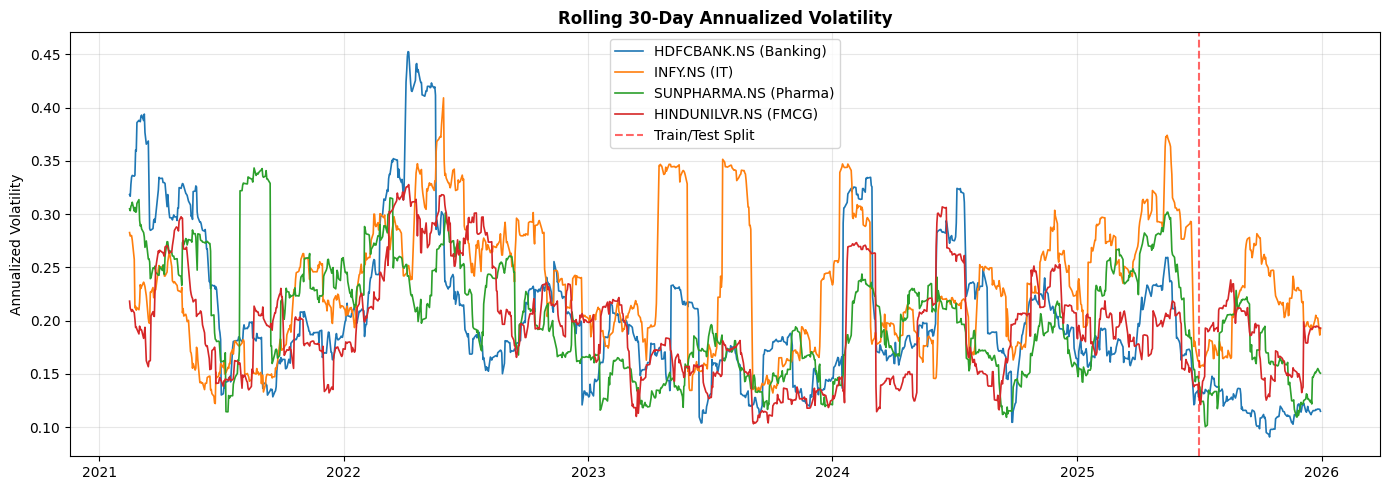

Volatility Summary:


,Avg Vol,Recent 30d Vol,Sector
Ticker,,,
HDFCBANK.NS,0.2015,0.1153,Banking
HINDUNILVR.NS,0.1947,0.1712,FMCG
INFY.NS,0.2329,0.2101,IT
SUNPHARMA.NS,0.2012,0.1294,Pharma


In [13]:
rolling_std = log_returns.rolling(window=ROLLING_WINDOW).std() * np.sqrt(252)

plt.figure(figsize=(14, 5))
for ticker in TICKER_LIST:
    plt.plot(rolling_std.index, rolling_std[ticker], label=f'{ticker} ({SECTOR_MAP[ticker]})', linewidth=1.2)

plt.axvline(pd.Timestamp(TEST_START), color='red', linestyle='--', alpha=0.6, label='Train/Test Split')
plt.title(f'Rolling {ROLLING_WINDOW}-Day Annualized Volatility', fontweight='bold')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/plots/03_rolling_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

avg_vol    = rolling_std.mean().rename('Avg Vol')
recent_vol = rolling_std.iloc[-30:].mean().rename('Recent 30d Vol')
vol_summary = pd.concat([avg_vol, recent_vol], axis=1).round(4)
vol_summary['Sector'] = [SECTOR_MAP[t] for t in vol_summary.index]
print('Volatility Summary:')
vol_summary

---
## 6. Correlation Heatmap

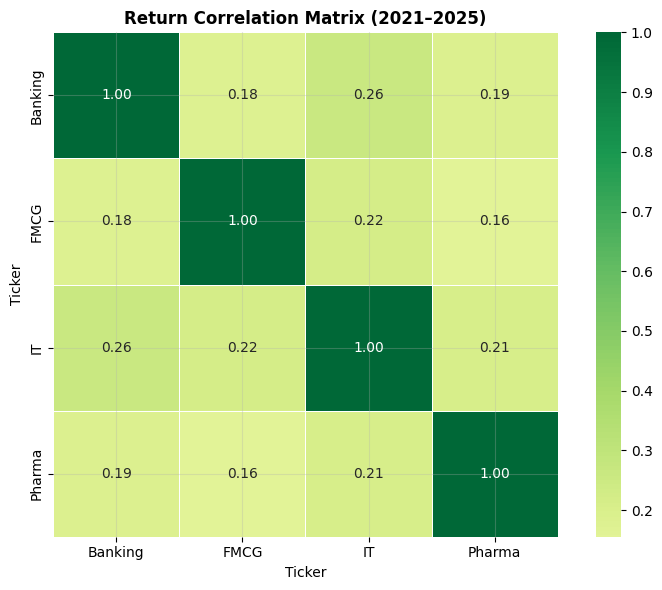

In [14]:
corr_matrix = log_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5,
    xticklabels=[SECTOR_MAP[t] for t in corr_matrix.columns],
    yticklabels=[SECTOR_MAP[t] for t in corr_matrix.index]
)
plt.title('Return Correlation Matrix (2021–2025)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. ADF Stationarity Test (Task 2)

In [15]:
def run_adf(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Stock'       : name,
        'ADF Stat'    : round(result[0], 4),
        'p-value'     : round(result[1], 4),
        'Stationary?' : 'YES' if result[1] < 0.05 else 'NO'
    }

print('=== Raw Close Prices ===')
print(pd.DataFrame([run_adf(close[t], t) for t in TICKER_LIST]).to_string(index=False))

print('\n=== Log Returns ===')
print(pd.DataFrame([run_adf(log_returns[t], t) for t in TICKER_LIST]).to_string(index=False))

=== Raw Close Prices ===
        Stock  ADF Stat  p-value Stationary?
  HDFCBANK.NS   -1.3959   0.5843          NO
      INFY.NS   -2.3999   0.1418          NO
 SUNPHARMA.NS   -0.8476   0.8047          NO
HINDUNILVR.NS   -2.8814   0.0475         YES

=== Log Returns ===
        Stock  ADF Stat  p-value Stationary?
  HDFCBANK.NS  -14.0585      0.0         YES
      INFY.NS  -33.5387      0.0         YES
 SUNPHARMA.NS  -37.1367      0.0         YES
HINDUNILVR.NS  -34.8013      0.0         YES


In [16]:
differenced = close.diff().dropna()

print('=== First-Differenced Prices ===')
print(pd.DataFrame([run_adf(differenced[t], t) for t in TICKER_LIST]).to_string(index=False))

=== First-Differenced Prices ===
        Stock  ADF Stat  p-value Stationary?
  HDFCBANK.NS  -14.0353      0.0         YES
      INFY.NS  -34.0327      0.0         YES
 SUNPHARMA.NS  -10.1058      0.0         YES
HINDUNILVR.NS  -35.1346      0.0         YES


---
## 8. STL Decomposition (Tasks 1 + 4)

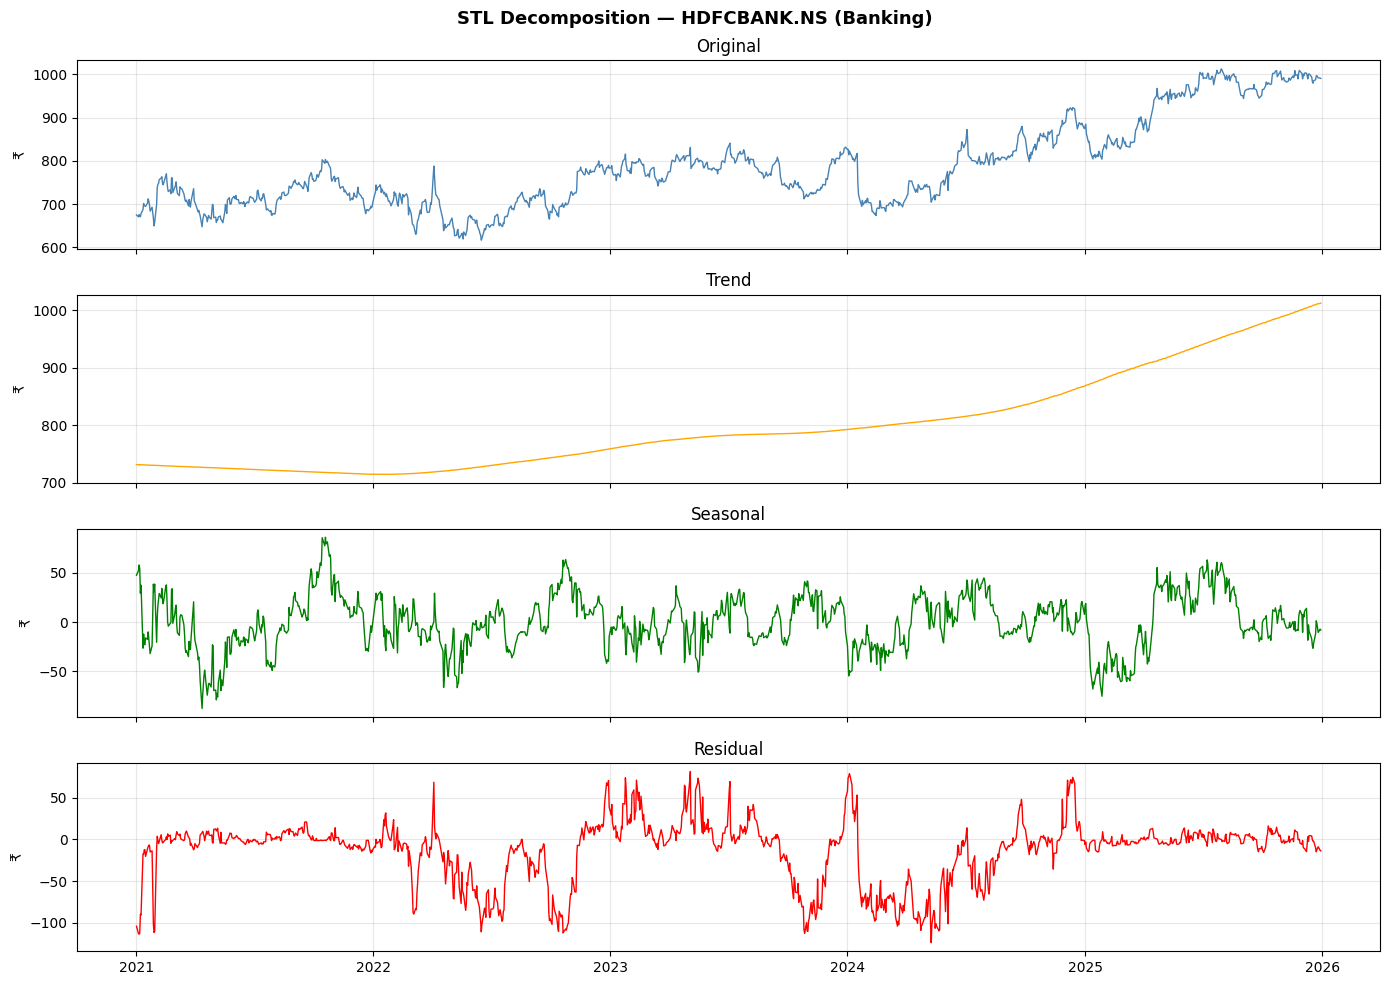

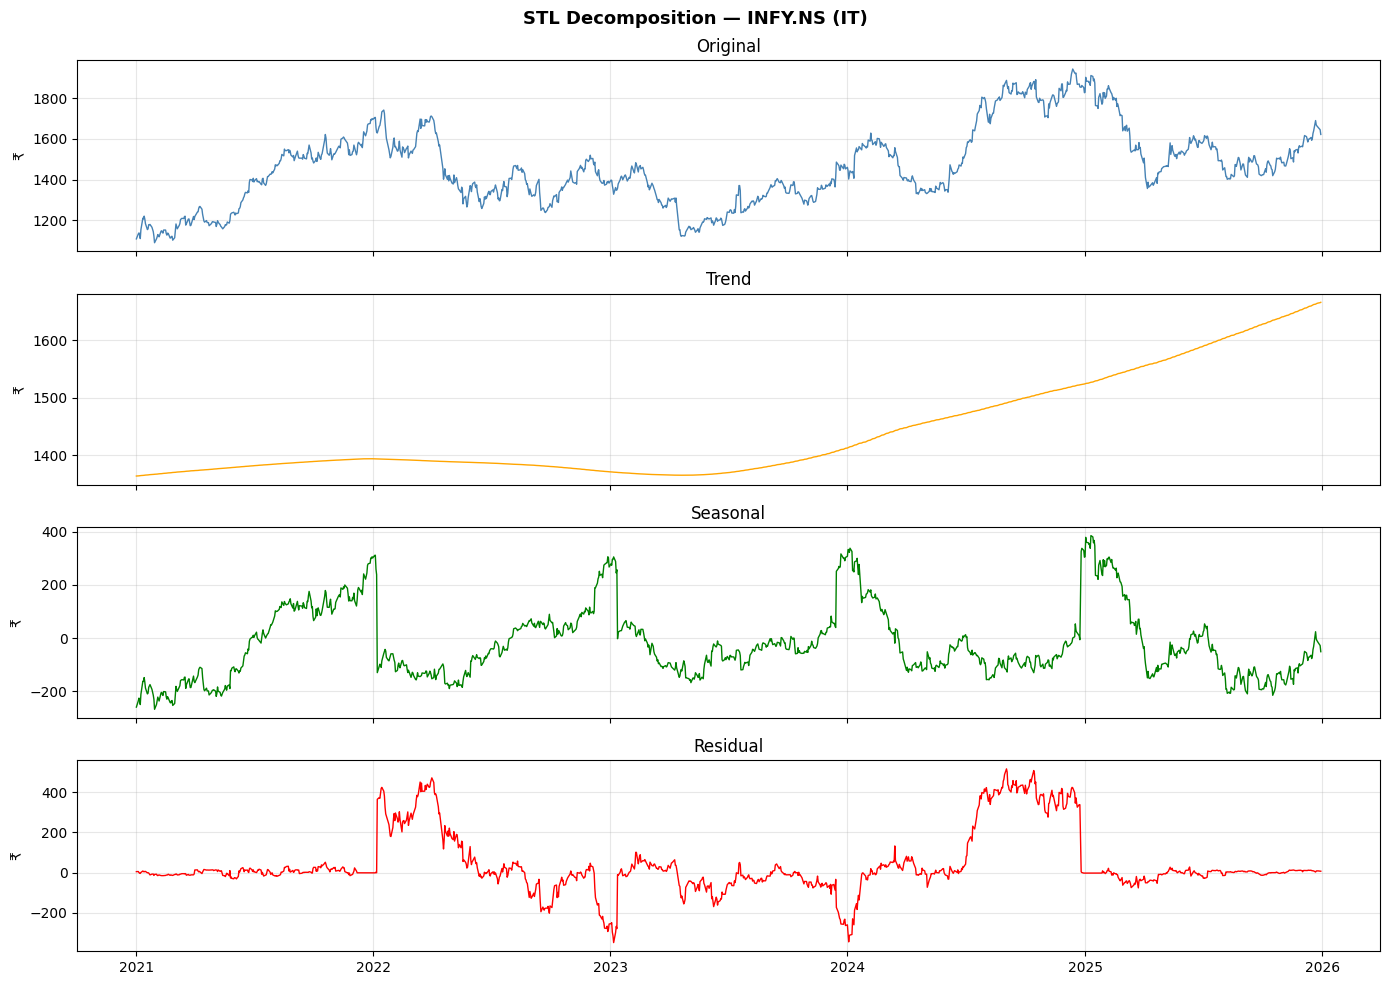

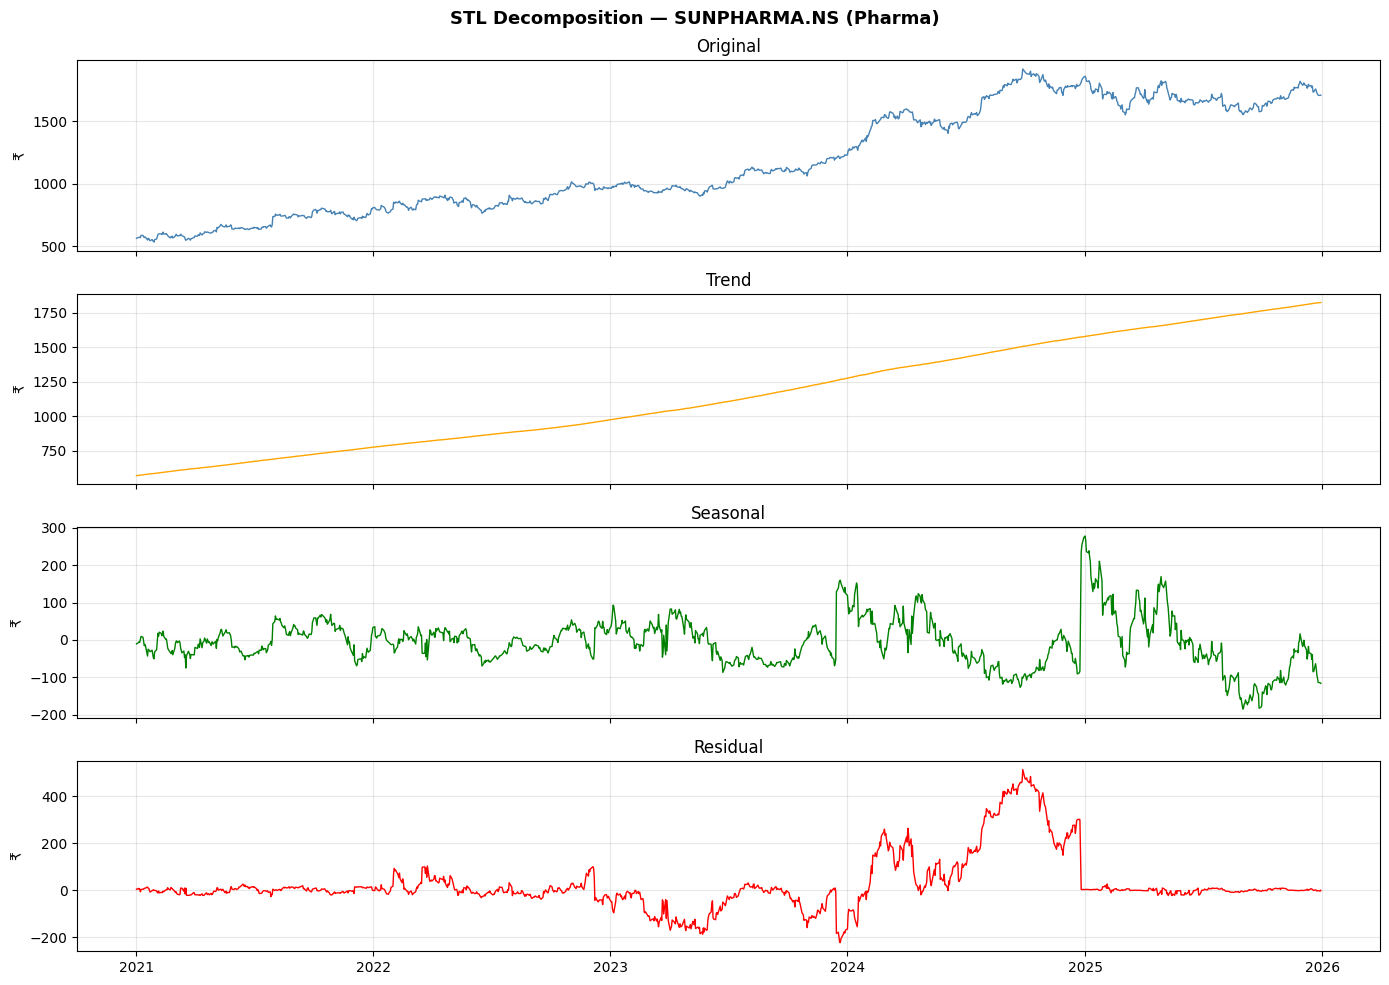

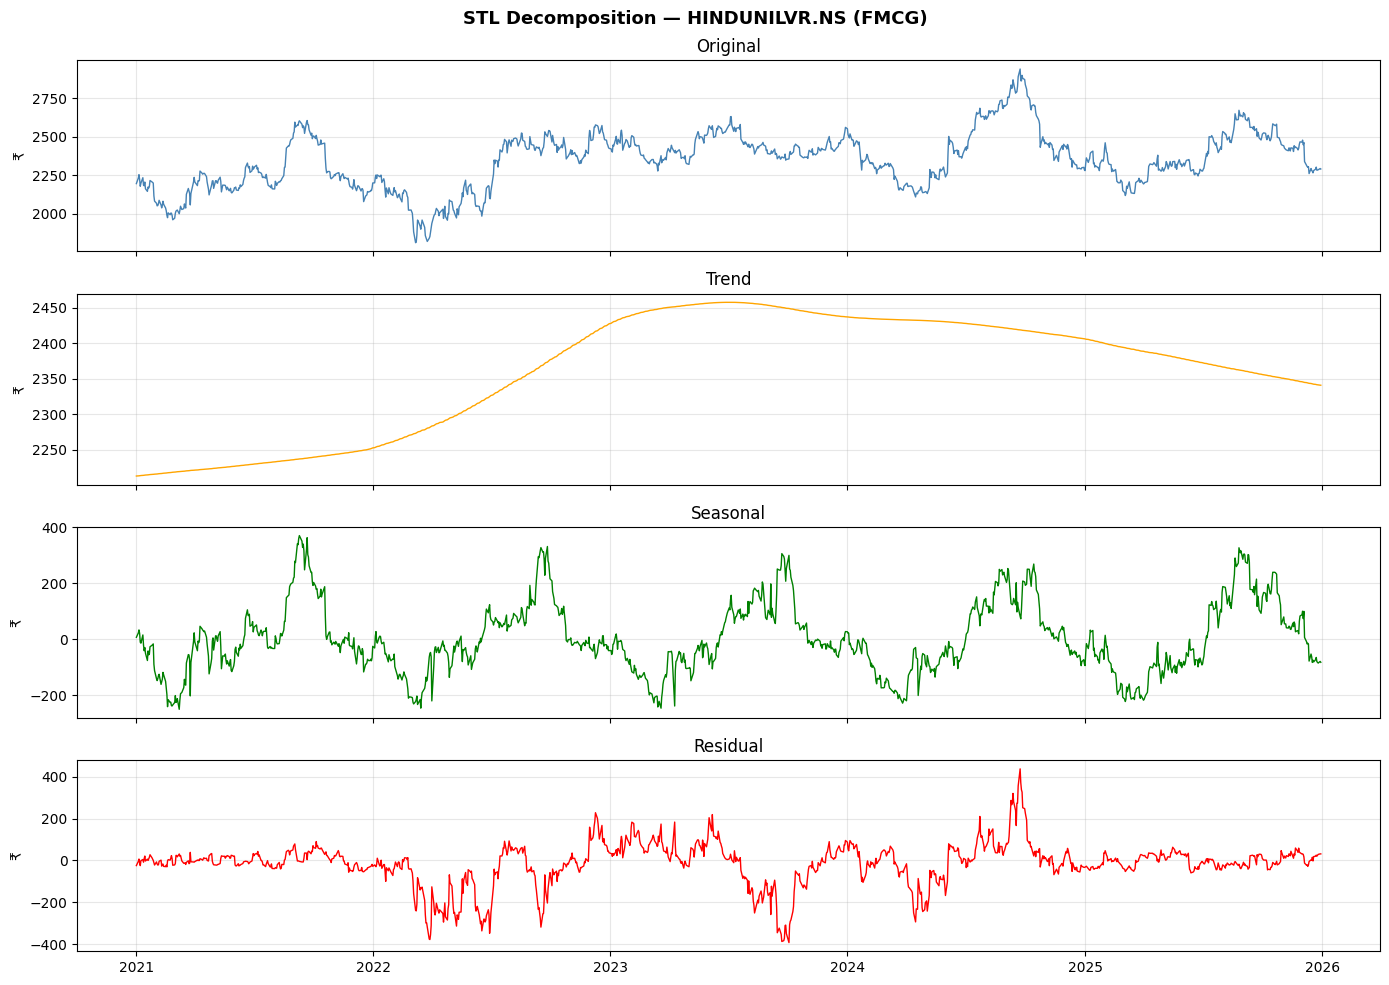

STL decomposition done.


In [17]:
stl_results = {}

for ticker in TICKER_LIST:
    series = close[ticker].dropna()
    stl    = STL(series, period=252, robust=True)  # 252 trading days = 1 year
    res    = stl.fit()
    stl_results[ticker] = res

    fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
    components = [
        (series.values, 'Original',   'steelblue'),
        (res.trend,     'Trend',      'orange'),
        (res.seasonal,  'Seasonal',   'green'),
        (res.resid,     'Residual',   'red')
    ]
    for ax, (vals, label, color) in zip(axes, components):
        ax.plot(series.index, vals, color=color, linewidth=1)
        ax.set_title(label)
        ax.set_ylabel('₹')

    plt.suptitle(f'STL Decomposition — {ticker} ({SECTOR_MAP[ticker]})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = f'../outputs/plots/05_stl_{ticker.replace(".","_")}.png'
    plt.savefig(fname, dpi=120, bbox_inches='tight')
    plt.show()

print('STL decomposition done.')

In [18]:
trend_summary = []
for ticker in TICKER_LIST:
    trend         = stl_results[ticker].trend
    recent_slope  = trend.iloc[-1] - trend.iloc[-60]   # change over last 60 trading days
    direction     = 'UPWARD' if recent_slope > 0 else 'DOWNWARD'
    trend_summary.append({
        'Stock'         : ticker,
        'Sector'        : SECTOR_MAP[ticker],
        'Recent Trend'  : direction,
        '60d Slope (₹)' : round(recent_slope, 2)
    })

trend_df = pd.DataFrame(trend_summary)
print('Trend Direction Summary (last 60 trading days):')
print(trend_df.to_string(index=False))

Trend Direction Summary (last 60 trading days):
        Stock  Sector Recent Trend  60d Slope (₹)
  HDFCBANK.NS Banking       UPWARD          34.34
      INFY.NS      IT       UPWARD          37.33
 SUNPHARMA.NS  Pharma       UPWARD          59.01
HINDUNILVR.NS    FMCG     DOWNWARD         -14.80


---
## 9. MinMaxScaler for LSTM (Task 2)

In [19]:
scalers      = {}
scaled_train = {}
scaled_test  = {}

for ticker in TICKER_LIST:
    scaler = MinMaxScaler(feature_range=(0, 1))

    train_vals = train_close[ticker].values.reshape(-1, 1)
    test_vals  = test_close[ticker].values.reshape(-1, 1)

    scaled_train[ticker] = scaler.fit_transform(train_vals).flatten()  # fit + transform
    scaled_test[ticker]  = scaler.transform(test_vals).flatten()       # transform only

    scalers[ticker] = scaler

print('Scalers fitted on train only.')
print('HDFCBANK scaled train range:',
      round(scaled_train['HDFCBANK.NS'].min(), 3), 'to',
      round(scaled_train['HDFCBANK.NS'].max(), 3))

Scalers fitted on train only.
HDFCBANK scaled train range: 0.0 to 1.0


---
## 10. Save All Outputs

In [20]:
with open('../data/processed/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

train_close.to_csv('../data/processed/train_close.csv')
test_close.to_csv('../data/processed/test_close.csv')
log_returns.to_csv('../data/processed/log_returns.csv')
differenced.to_csv('../data/processed/differenced_close.csv')
rolling_std.to_csv('../data/processed/rolling_volatility.csv')

pd.DataFrame(scaled_train, index=train_close.index).to_csv('../data/processed/scaled_train.csv')
pd.DataFrame(scaled_test,  index=test_close.index).to_csv('../data/processed/scaled_test.csv')

print('Saved files:')
for f in sorted(os.listdir('../data/processed')):
    print(' -', f)

Saved files:
 - differenced_close.csv
 - log_returns.csv
 - rolling_volatility.csv
 - scaled_test.csv
 - scaled_train.csv
 - scalers.pkl
 - test_close.csv
 - train_close.csv


---
## 11. Summary

In [21]:
print('=' * 55)
print('NOTEBOOK 01 — SUMMARY')
print('=' * 55)

print('\n[Task 1] Stock Universe (5 sectors):')
for sector, ticker in TICKERS.items():
    print(f'  {sector:10} → {ticker}')

print('\n[Task 2] Stationarity conclusion:')
print('  Raw prices  → Non-stationary | ARIMA needs d=1')
print('  Log returns → Stationary     | Input for GARCH')
print('  LSTM        → Scaled raw prices (no differencing)')

print('\n[Task 1/4] Trend directions:')
for _, row in trend_df.iterrows():
    print(f"  {row['Stock']:22} → {row['Recent Trend']}")

print('\n[Task 4] Recent volatility:')
for ticker in TICKER_LIST:
    v     = vol_summary.loc[ticker, 'Recent 30d Vol']
    label = 'HIGH' if v > 0.30 else ('MED' if v > 0.20 else 'LOW')
    print(f'  {ticker:22} → {v:.4f} annualized  [{label}]')

NOTEBOOK 01 — SUMMARY

[Task 1] Stock Universe (5 sectors):
  Banking    → HDFCBANK.NS
  IT         → INFY.NS
  Pharma     → SUNPHARMA.NS
  FMCG       → HINDUNILVR.NS

[Task 2] Stationarity conclusion:
  Raw prices  → Non-stationary | ARIMA needs d=1
  Log returns → Stationary     | Input for GARCH
  LSTM        → Scaled raw prices (no differencing)

[Task 1/4] Trend directions:
  HDFCBANK.NS            → UPWARD
  INFY.NS                → UPWARD
  SUNPHARMA.NS           → UPWARD
  HINDUNILVR.NS          → DOWNWARD

[Task 4] Recent volatility:
  HDFCBANK.NS            → 0.1153 annualized  [LOW]
  INFY.NS                → 0.2101 annualized  [MED]
  SUNPHARMA.NS           → 0.1294 annualized  [LOW]
  HINDUNILVR.NS          → 0.1712 annualized  [LOW]

